# The same model, at 145 zones

You have run this model before. The fifteen-zone notebook weighted every origin-destination pair by its generalised cost and then balanced the matrix until the row totals matched resident workers and the column totals matched jobs. This notebook does the same thing over the 145 MSOAs that the fifteen zones were built from. Nothing about the method has changed. Only the number of cells has.

Fifteen zones gave you 225 cells, which fits on a screen and which you could read across in a minute. The 145 MSOAs give you 21,025, ninety-three times as many, and not one new way of checking any of them.

So, the only verification available here is the one you could have stated before the model ran. A doubly constrained model is constrained to reproduce the margins it was handed, and if the row and column totals do not come back to the trip ends you fed in, nothing else in the matrix is worth reading. That is a narrow check. It is also the whole of what the model guarantees, and at this scale it is what you have.

There is a second thing to carry through the exercise, and it is the one I would most want you to leave with. A convergence report tells you that the balancing stopped. It does not tell you the answer is right. A model fed the wrong cost matrix converges just as one fed the right cost matrix, and it converges to a wrong answer with a tidy iteration count attached, which is precisely what the fifteen-zone model did when it was handed distances in kilometres and a beta calibrated per minute. Tolerance is a stopping rule chosen by whoever wrote the model. It is not a measure of quality.

Of everything printed below, the convergence report is the output most likely to be mistaken for a certificate of correctness. That mistake is an easy one to make, and the layout invites it: the report carries a verdict word and a count of iterations, and it appears at the end of the run rather than beside the inputs, which is where a check on the data would have to sit if it were going to catch anything.

Work through the sections in order, from the top of the page to the bottom.

## Where the files are

JupyterLite runs inside your browser. Nothing is installed on your machine and you do not need administrator rights, which is why this page opens on a locked-down work machine.

The notebook and its data arrived with the site, so there is nothing to download and nothing to upload. Open the file browser - the panel down the left-hand side, or the folder icon in the far-left sidebar if it is not showing - and you will find this arrangement already in place:

```
tyne-and-wear-msoa/
    msoa-model-first-run.ipynb
    data/
        zones_msoa.csv
        flows_msoa.csv
        trip_ends_msoa.csv
        cost_matrix_msoa.csv
```

Every path in the code below assumes it. The notebook sits at the top of the folder and the data sits one level under it, so moving either one will break the loading section.

**What happens to anything you change**

Because there is no server behind this, whatever you save goes into your browser's own storage rather than onto a network drive. That has two consequences: anything you want to keep should be
downloaded - right-click the file in the file browser and choose **Download**. And if you clear your browsing data, or if your employer's IT policy clears it for you, your saved work goes with it.

Do not edit the CSV files. If you want to try something out on them, duplicate one first and work on the copy.

**Getting back to the original**

Should you change the notebook and want the version you started with, use **Help > Clear Browser Data**. But read the warning it gives you before confirming. It removes everything you have stored on this site, for every notebook here, and it cannot be undone, so download anything you care about
first.

## Checking the files are where you think they are

Run the cell below before anything else. It reports what it can see, which is
faster than reading an error message later and guessing what went wrong.

In [1]:
import os

DATA_FOLDER = "data"

expected = [
    "zones_msoa.csv",
    "flows_msoa.csv",
    "trip_ends_msoa.csv",
    "cost_matrix_msoa.csv",
]

print("Looking in:", os.path.abspath(DATA_FOLDER))
print()

if not os.path.isdir(DATA_FOLDER):
    print("That folder does not exist yet.")
    print("Check the folder names and check where this notebook is saved.")
else:
    found = sorted(os.listdir(DATA_FOLDER))
    for name in expected:
        status = "found" if name in found else "MISSING"
        print(f"  {name:24s} {status}")

Looking in: /drive/tyne-and-wear/tyne-and-wear-msoa/data

  zones_msoa.csv           found
  flows_msoa.csv           found
  trip_ends_msoa.csv       found
  cost_matrix_msoa.csv     found


## Parameters

This is the only cell in the notebook you will change. Everything below it reads these four values and does as it is told.

Two of the four move today, and only two: MAX_ITERATIONS and TOLERANCE. BETA stays at 0.1185, which is the value you used in the spreadsheet and in the fifteen-zone notebook, and DETERRENCE stays exponential. What beta does to the shape of a matrix is the subject of the next exercise in this sequence, and moving it here would tangle two questions that are worth keeping apart.

In [2]:
# ---------------------------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------------------------

BETA = 0.1185            # sensitivity to generalised cost, per minute

DETERRENCE = "exponential"   # "exponential" or "power"

MAX_ITERATIONS = 100     # most balancing iterations the model is allowed

TOLERANCE = 0.01         # a row or column total this close to its target,
                         # in trips, counts as matched

# ---------------------------------------------------------------------------

## Loading the data

Four files go in. The zone list fixes the order of everything else, so that row three of the cost matrix and row three of the trip ends refer to the same place. What gets read from each matters, because a column name is the sort of thing that goes wrong quietly: `zone_id` and `zone_name` from the zone list, `origin_id`, `destination_id` and `trips` from the flows file, `origin_id`, `destination_id` and `gc_min` from the cost matrix, and `zone_id`, `resident_workers` and `jobs` from the trip ends. The `jobs` column lives in the trip-ends file rather than in the opportunities file, which counts something different.

This is the slowest cell in the notebook. The cost matrix is 21,025 rows, so give it a moment before deciding it has stalled.

In [3]:
import numpy as np
import pandas as pd

zones = pd.read_csv(f"{DATA_FOLDER}/zones_msoa.csv", encoding="utf-8-sig")
flows = pd.read_csv(f"{DATA_FOLDER}/flows_msoa.csv", encoding="utf-8-sig")
costs = pd.read_csv(f"{DATA_FOLDER}/cost_matrix_msoa.csv", encoding="utf-8-sig")
trip_ends = pd.read_csv(f"{DATA_FOLDER}/trip_ends_msoa.csv", encoding="utf-8-sig")

zone_ids = list(zones["zone_id"])
zone_names = dict(zip(zones["zone_id"], zones["zone_name"]))

print(f"Zones loaded:            {len(zone_ids)}")
print(f"Flow records:            {len(flows):,}")
print(f"Cost matrix records:     {len(costs):,}")
print(f"Trip end records:        {len(trip_ends)}")

Zones loaded:            145
Flow records:            16,535
Cost matrix records:     21,025
Trip end records:        145


The two long files are lists, one row per origin-destination pair, and the model needs them as grids of 145 rows by 145 columns. The next cell reshapes them and pulls out the row and column totals the model has to reproduce.

The flows file is shorter than the cost matrix, 16,535 rows against 21,025. Every ordered pair of zones has a cost. Not every pair was recorded carrying a commuter in 2011, and the pairs with none are simply absent from the file rather than present with a zero. Take that as a fact about the data for now. What to make of it comes later in this sequence.

In [4]:
observed = (flows
            .pivot(index="origin_id", columns="destination_id", values="trips")
            .reindex(index=zone_ids, columns=zone_ids)
            .fillna(0)
            .values.astype(float))

cost = (costs
        .pivot(index="origin_id", columns="destination_id", values="gc_min")
        .reindex(index=zone_ids, columns=zone_ids)
        .values.astype(float))

margins = trip_ends.set_index("zone_id").reindex(zone_ids)
origins = margins["resident_workers"].values.astype(float)
destinations = margins["jobs"].values.astype(float)

print("Observed matrix:", observed.shape)
print("Cost matrix:    ", cost.shape)

Observed matrix: (145, 145)
Cost matrix:     (145, 145)


## Looking at what you have been handed

Before running anything, confirm two things on the screen below. The cost matrix should hold one row for every ordered pair of the 145 zones, which is 21,025 including each zone with itself. And the resident workers should sum to the same total as the jobs, because a doubly constrained model cannot reconcile margins that disagree about how many trips exist.

Glance at the range of the trip ends as well. It tells you what a discrepancy of a few hundred trips would mean, and that answer is different in a zone of 1,458 resident workers from what it is in one of 43,214 jobs.

In [5]:
print(f"Zones:                       {len(zone_ids)}")
print(f"Ordered pairs expected:      {len(zone_ids) ** 2:,}")
print(f"Cost matrix rows supplied:   {len(costs):,}")
print(f"Flow rows supplied:          {len(flows):,}")
print()
print(f"Resident workers, total:     {origins.sum():,.0f}")
print(f"Jobs, total:                 {destinations.sum():,.0f}")
print(f"Difference:                  {origins.sum() - destinations.sum():,.0f}")
print()
print(f"Resident workers per zone:   {origins.min():,.0f} to {origins.max():,.0f}")
print(f"Jobs per zone:               {destinations.min():,.0f} to {destinations.max():,.0f}")

Zones:                       145
Ordered pairs expected:      21,025
Cost matrix rows supplied:   21,025
Flow rows supplied:          16,535

Resident workers, total:     371,585
Jobs, total:                 371,585
Difference:                  0

Resident workers per zone:   1,458 to 4,135
Jobs per zone:               184 to 43,214


In [6]:
print("Generalised cost, minutes")
print(f"  lowest              {cost.min():6.2f}")
print(f"  highest             {cost.max():6.2f}")
print(f"  mean over all pairs {cost.mean():6.2f}")
print()
print(f"Values in the cost matrix: {cost.size:,}")

Generalised cost, minutes
  lowest                0.85
  highest              75.59
  mean over all pairs  27.16

Values in the cost matrix: 21,025


## The deterrence function

One line of arithmetic turns a cost into a weight. High cost, low weight. This is the exponential form you used in the spreadsheet, with the same beta, and the only difference is that 21,025 costs go through it instead of 225.

In [7]:
if DETERRENCE == "exponential":
    deterrence = np.exp(-BETA * cost)
elif DETERRENCE == "power":
    deterrence = cost ** (-BETA)
else:
    raise ValueError('DETERRENCE must be "exponential" or "power"')

print(f"Deterrence function: {DETERRENCE}, beta = {BETA}")
print(f"Weight on the cheapest pair ({cost.min():.2f} min): {deterrence.max():.4f}")
print(f"Weight on the dearest pair ({cost.max():.2f} min):  {deterrence.min():.4f}")

Deterrence function: exponential, beta = 0.1185
Weight on the cheapest pair (0.85 min): 0.9042
Weight on the dearest pair (75.59 min):  0.0001


## Running the model

The balancing loop is the part you did by hand in the workbook. Scale the rows so they match resident workers, scale the columns so they match jobs, find that the rows have drifted out again, and go round once more. Repeat until the drift is small enough, where small enough is whatever TOLERANCE says it is.

Because each iteration scales the columns last, the column totals come back exact and whatever drift remains shows up in the rows. That is an artefact of the order in which the two scalings are applied, not a property of Tyne and Wear, and it means the row error is the number to watch in the report below.

One caution about the word itself. This model counts an iteration as a row scaling followed by a column scaling, so the thirteen it reports would be twenty-six under the convention that counts each scaling separately. A model report stating that balancing converged in twenty iterations does not, on its own, tell you which of the two produced that number.

In [8]:
row_factor = np.ones(len(zone_ids))
col_factor = np.ones(len(zone_ids))

history = []

for iteration in range(1, MAX_ITERATIONS + 1):

    row_factor = 1.0 / (deterrence * (col_factor * destinations)).sum(axis=1)
    col_factor = 1.0 / (deterrence * (row_factor * origins)[:, None]).sum(axis=0)

    modelled = ((row_factor * origins)[:, None]
                * (col_factor * destinations)[None, :]
                * deterrence)

    row_error = np.abs(modelled.sum(axis=1) - origins).max()
    col_error = np.abs(modelled.sum(axis=0) - destinations).max()
    worst = max(row_error, col_error)

    history.append((iteration, row_error, col_error))

    if worst < TOLERANCE:
        break

print("CONVERGENCE REPORT")
print("-" * 46)
print(f"Iterations run:        {iteration}")
print(f"Iterations allowed:    {MAX_ITERATIONS}")
print(f"Tolerance required:    {TOLERANCE} trips")
print(f"Worst row error:       {row_error:.4f} trips")
print(f"Worst column error:    {col_error:.4f} trips")
print()
if worst < TOLERANCE:
    print("Converged.")
else:
    print("DID NOT CONVERGE within the iteration limit.")
    print("The matrix below does not match its margins. Do not use it.")

CONVERGENCE REPORT
----------------------------------------------
Iterations run:        13
Iterations allowed:    100
Tolerance required:    0.01 trips
Worst row error:       0.0093 trips
Worst column error:    0.0000 trips

Converged.


In [9]:
print("Worst error remaining after each iteration, in trips")
print()
for iteration_number, row_err, col_err in history[:20]:
    worst_here = max(row_err, col_err)
    print(f"  iteration {iteration_number:3d}   {worst_here:12.4f}")
if len(history) > 20:
    print(f"  ... {len(history) - 20} further iterations")

Worst error remaining after each iteration, in trips

  iteration   1       516.1017
  iteration   2        99.7923
  iteration   3        22.1575
  iteration   4         5.4430
  iteration   5         1.8947
  iteration   6         0.6880
  iteration   7         0.2542
  iteration   8         0.1388
  iteration   9         0.0784
  iteration  10         0.0453
  iteration  11         0.0266
  iteration  12         0.0157
  iteration  13         0.0093


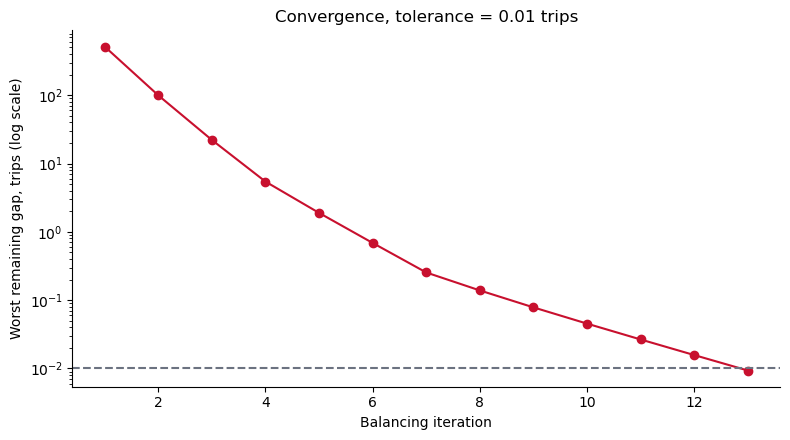

In [10]:
import matplotlib.pyplot as plt

iterations = [h[0] for h in history]
worst_by_iteration = [max(h[1], h[2]) for h in history]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(iterations, worst_by_iteration, marker="o", color="#C8102E")
ax.axhline(TOLERANCE, linestyle="--", color="#6B7280")
ax.set_yscale("log")
ax.set_xlabel("Balancing iteration")
ax.set_ylabel("Worst remaining gap, trips (log scale)")
ax.set_title(f"Convergence, tolerance = {TOLERANCE} trips")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## The check that has to be made

State the rule before you look at the answer, because a check you formulate after seeing the output is not a check.

The rule is this: every zone's modelled outward trips must equal its resident workers and every zone's modelled inward trips must equal its jobs, to within TOLERANCE. A doubly constrained model that fails this has not merely produced a poor forecast. It has failed to do the one thing its own structure promises, and the 21,025 cells underneath are not worth interpreting.

Printing all 145 rows would fill the screen and would not be read, so the cell below prints the ten largest discrepancies and counts how many zones sit outside tolerance. Two questions to hold while you read it. What would you conclude if a single zone were out by four hundred trips, and what would you conclude instead if every zone were out by four hundred? They are not the same fault, and they do not have the same cause.

In [11]:
row_gap = modelled.sum(axis=1) - origins
col_gap = modelled.sum(axis=0) - destinations

check = pd.DataFrame({
    "zone": [zone_names[z] for z in zone_ids],
    "target_out": origins.astype(int),
    "modelled_out": modelled.sum(axis=1).round(2),
    "row_gap": row_gap.round(2),
    "target_in": destinations.astype(int),
    "modelled_in": modelled.sum(axis=0).round(2),
    "col_gap": col_gap.round(2),
})
check.index = zone_ids

outside = int((np.abs(row_gap) >= TOLERANCE).sum()
              + (np.abs(col_gap) >= TOLERANCE).sum())

print(f"Zone margins outside tolerance: {outside} of {2 * len(zone_ids)}")
print()
print("Ten largest row discrepancies")
print(check.reindex(check["row_gap"].abs().sort_values(ascending=False).index)
      .head(10)
      .to_string())

Zone margins outside tolerance: 0 of 290

Ten largest row discrepancies
                                  zone  target_out  modelled_out  row_gap  target_in  modelled_in  col_gap
E02001808                  Barnes Park        2073       2073.01     0.01       1023       1023.0     -0.0
E02001818                       Ryhope        2712       2712.01     0.01       1036       1036.0     -0.0
E02001801                    Millfield        2129       2129.01     0.01       4702       4702.0      0.0
E02001806               Hendon & Docks        2361       2361.01     0.01       2906       2906.0      0.0
E02001796                Monkwearmouth        3205       3205.01     0.01       2906       2906.0     -0.0
E02001811        Pennywell and Grindon        2896       2896.01     0.01       1114       1114.0      0.0
E02001812         Hill View & Tunstall        3473       3473.01     0.01       1730       1730.0      0.0
E02001813  Thorney Close & Plains Farm        2869       2869.01     0.0

## Stopping early, on purpose

Your spreadsheet stopped after three iterations, with the model still out of balance, because the instructions told you to stop there. Set MAX_ITERATIONS to 3 in the parameters cell and run the notebook again from the top, and you have the same stopping rule applied to a model ninety-three times the size. 

The panel below is what to compare. It prints the worst remaining gap, the zone it falls in, and that gap as a share of the zone's own resident workers, against the figures from the fifteen-zone workbook. The absolute number and the share point in different directions. But the share is the one that matters.

In [12]:
worst_index = int(np.abs(row_gap).argmax())
worst_zone = zone_ids[worst_index]
worst_gap = float(np.abs(row_gap)[worst_index])
worst_target = float(origins[worst_index])

modelled_mean_cost = (modelled * cost).sum() / modelled.sum()

print("THIS RUN")
print("-" * 62)
print(f"Iterations used:          {iteration}")
print(f"Worst remaining gap:      {worst_gap:.2f} trips")
print(f"In zone:                  {zone_names[worst_zone]} ({worst_zone})")
print(f"That zone's resident workers: {worst_target:,.0f}")
print(f"Gap as a share of them:   {worst_gap / worst_target:.2%}")
print(f"Mean cost of a modelled trip: {modelled_mean_cost:.4f} minutes")
print()
print("YOUR FIFTEEN-ZONE WORKBOOK, AFTER THREE ITERATIONS")
print("-" * 62)
print("Worst remaining gap:      97.77 trips")
print("In zone:                  North Shields and Whitley Bay (Z10)")
print("That zone's resident workers: 29,876")
print("Gap as a share of them:   0.33%")

THIS RUN
--------------------------------------------------------------
Iterations used:          13
Worst remaining gap:      0.01 trips
In zone:                  Hill View & Tunstall (E02001812)
That zone's resident workers: 3,473
Gap as a share of them:   0.00%
Mean cost of a modelled trip: 14.3896 minutes

YOUR FIFTEEN-ZONE WORKBOOK, AFTER THREE ITERATIONS
--------------------------------------------------------------
Worst remaining gap:      97.77 trips
In zone:                  North Shields and Whitley Bay (Z10)
That zone's resident workers: 29,876
Gap as a share of them:   0.33%


## Changing where the model stops

Restore MAX_ITERATIONS to 100 before going on, then change TOLERANCE. Loosen it first, then tighten it well below where it started, running the whole notebook from the top each time. For each run write down the iterations used, the worst remaining gap, and the mean cost of a modelled trip from the panel above.

Do not decide in advance what you expect to see. Write the numbers down, put them beside each other, and say what the iteration count is telling you about the matrix.

## Taking the results away with you

Anything you want to keep has to leave the browser. Nothing here persists: the files live in your browser's storage, and a cleared cache takes them with it.

The cell below writes the modelled matrix and the zone totals as CSV files, which open in Excel without any conversion. Find each one in the file browser panel on the left, right-click, and choose **Download**. Keep the matrix somewhere you can find it, because you will need it again later in this sequence.

In [13]:
matrix_out = pd.DataFrame(modelled.round(2), index=zone_ids, columns=zone_ids)
matrix_out.index.name = "origin_id"

outputs = {
    "results_msoa_matrix.csv": matrix_out,
    "results_msoa_zone_totals.csv": check,
}

for filename, table in outputs.items():
    table.to_csv(filename, encoding="utf-8-sig")
    print(f"Written: {filename}")

print()
print("Right-click each one in the file browser and choose Download.")

Written: results_msoa_matrix.csv
Written: results_msoa_zone_totals.csv

Right-click each one in the file browser and choose Download.


## What this run established

You have a matrix of 21,025 cells whose row totals match resident workers and whose column totals match jobs. That is the whole of what has been demonstrated. The cost matrix could have been in the wrong units, the trip ends could have come
from the wrong year, and the report would have printed the same reassuring word.

Which is why the verification note you write up asks what a converged run does
and does not establish, rather than asking what the model found.